# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`. 

# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district 
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [10]:
df = pd.read_csv("../data/housing.csv")

# take a look at the dataset
print(df.head())
df.tail()

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [11]:
# summarize the data
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [12]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

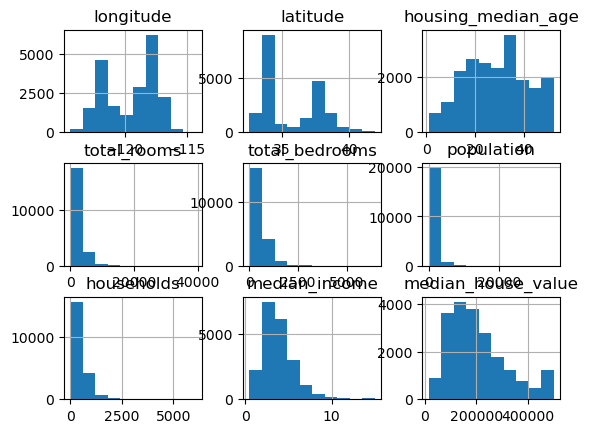

In [13]:
viz = df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value']]
viz.hist()
plt.show()


#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you. 

In [14]:
# Check for missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [15]:
# Dropping column 'total bedrooms' 
df["total_bedrooms"].fillna(df["total_bedrooms"].mean(), inplace=True)
df.isnull().sum()

C:\Users\Antonio\AppData\Local\Temp\ipykernel_8156\4007761351.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].mean(), inplace=True)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [16]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]



In [17]:
df["population_per_household"] = df["population"] / df["households"]

In [18]:
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,2.555556,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,2.109842,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,2.802260,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,2.547945,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,2.181467,0.172096


3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [20]:
print(df["rooms_per_household"].nlargest(2))   # top 2 outliers
print(df["rooms_per_household"].nsmallest(2))  # bottom 2 wrong values

1914    141.909091
1979    132.533333
Name: rooms_per_household, dtype: float64
5916    0.846154
8219    0.888889
Name: rooms_per_household, dtype: float64


In [21]:
df.drop(index=[1914, 1979, 5916, 8219], inplace=True)

In [22]:
print(df["rooms_per_household"].nlargest(2))   # top 2 outliers
print(df["rooms_per_household"].nsmallest(2))  # bottom 2 wrong values

12447    62.422222
1913     61.812500
Name: rooms_per_household, dtype: float64
3126     1.000000
14818    1.130435
Name: rooms_per_household, dtype: float64


In [23]:
print(df.shape)          # confirm 4 rows removed
df["rooms_per_household"].describe()   # check min/max look reasonable now

(20636, 13)


count    20636.000000
mean         5.416669
std          2.105933
min          1.000000
25%          4.440869
50%          5.229129
75%          6.052195
max         62.422222
Name: rooms_per_household, dtype: float64

# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

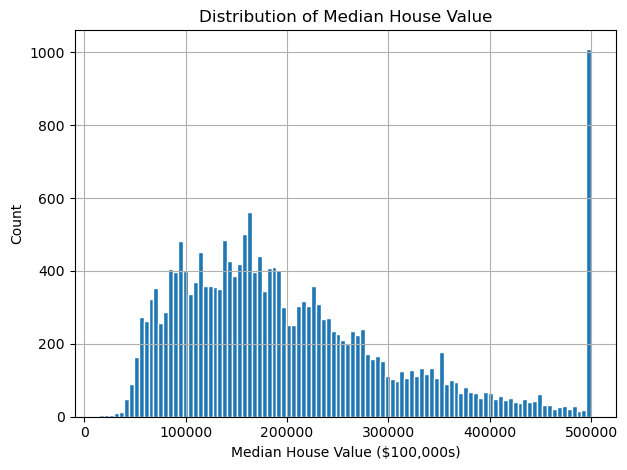

In [24]:
import matplotlib.pyplot as plt

df["median_house_value"].hist(bins=100, edgecolor="white")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.title("Distribution of Median House Value")
plt.tight_layout()
plt.show()

2. Check out what variables correlates the most with "median house value"

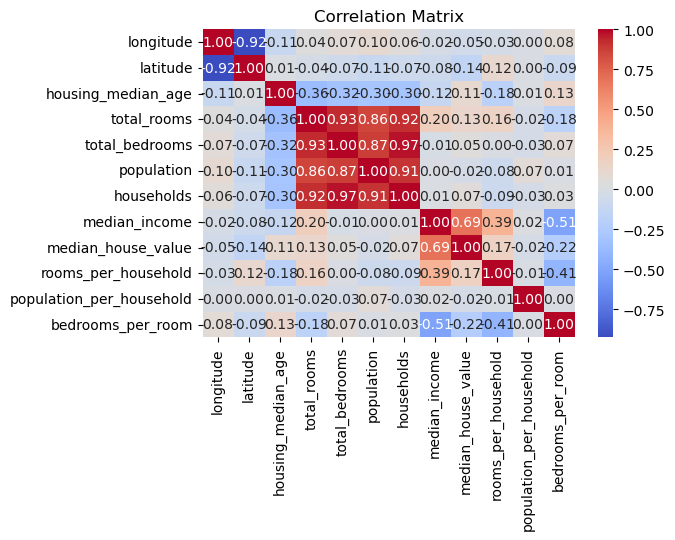

In [31]:
import seaborn as sns
# df.dtypes
# print(df.isnull().sum())

df_corr = df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income','median_house_value','rooms_per_household','population_per_household','bedrooms_per_room']]

# Computing Correlation Matrix
df_corr_matrix = df_corr.corr()

# Generating a Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

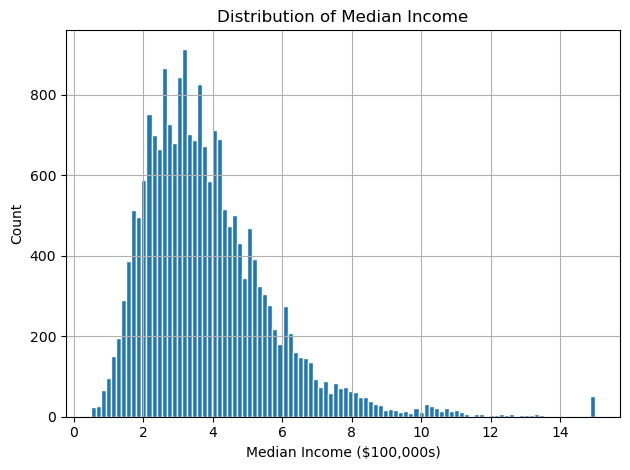

In [33]:
import matplotlib.pyplot as plt

df["median_income"].hist(bins=100, edgecolor="white")
plt.xlabel("Median Income ($100,000s)")
plt.ylabel("Count")
plt.title("Distribution of Median Income")
plt.tight_layout()
plt.show()

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

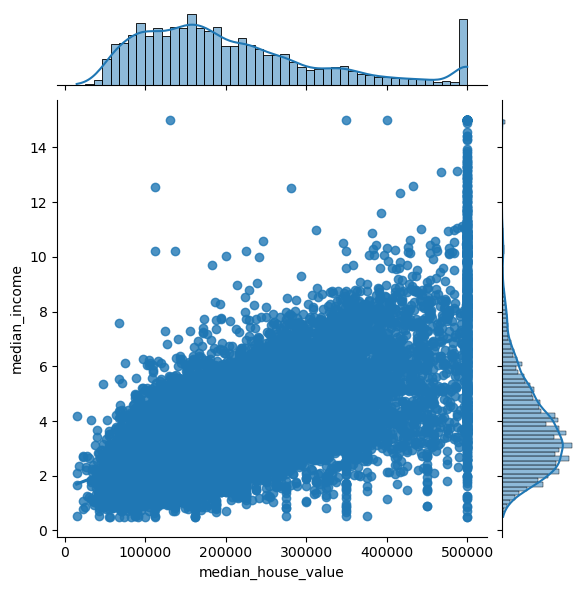

In [36]:
import seaborn as sns

sns.jointplot(x="median_house_value", y="median_income", data=df, kind="reg")

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

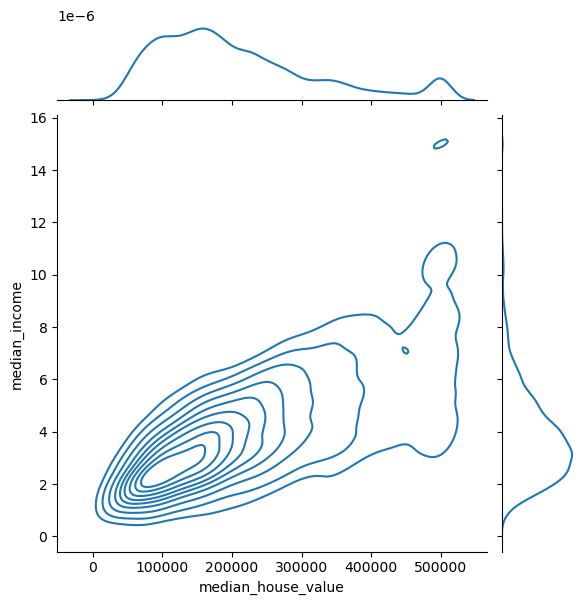

In [37]:
sns.jointplot(x="median_house_value", y="median_income", data=df, kind="kde")

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [38]:
df["income_cat"] = pd.qcut(
    df["median_income"],
    q=[0, 0.25, 0.5, 0.75, 0.95, 1],
    labels=["Low", "Below_Average", "Above_Average", "High", "Very High"]
)

# Check the result
print(df[["median_income", "income_cat"]].head())

   median_income     income_cat
0         8.3252      Very High
1         8.3014      Very High
2         7.2574           High
3         5.6431           High
4         3.8462  Above_Average


2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

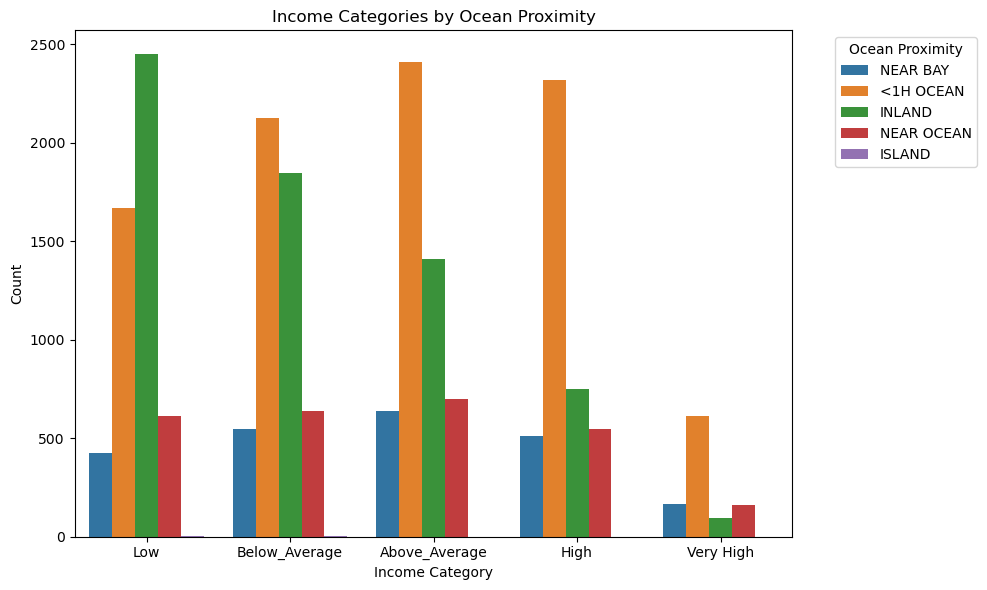

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="income_cat",
    hue="ocean_proximity",
    order=["Low", "Below_Average", "Above_Average", "High", "Very High"]
)

plt.title("Income Categories by Ocean Proximity")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Ocean Proximity", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# "INLAND" shrinks when INCOME GROWS, as indication that 
# proximity to the coast is associated with higher median incomes in this dataset.

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

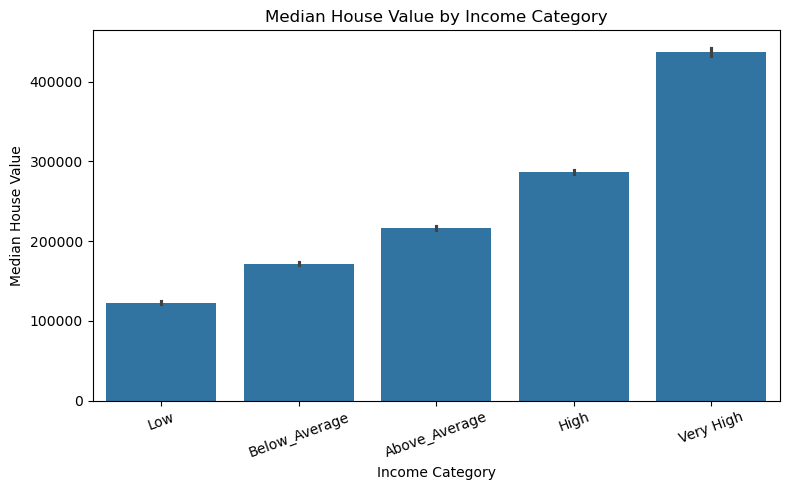

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot 1: Median House Value by Income Category
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="income_cat",
    y="median_house_value",
    order=["Low", "Below_Average", "Above_Average", "High", "Very High"]
)

plt.title("Median House Value by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Median House Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()





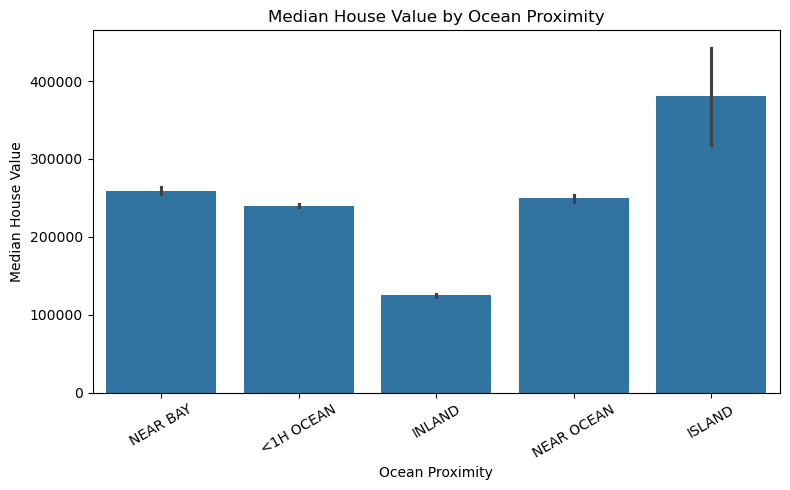

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot 2: Median House Value by Ocean Proximity
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value"
)

plt.title("Median House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# This is a good indication that both median_income and ocean_proximity 
# are important features for predicting median_house_value, 
# and they may also interact with each other in a machine learning model.

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [45]:
import pandas as pd

# Create pivot table (counts)
income_ocean_pivot = pd.crosstab(
    index=df["income_cat"],
    columns=df["ocean_proximity"]
)



In [46]:
# Drop the ISLAND column
income_ocean_pivot = income_ocean_pivot.drop(columns="ISLAND")

# Display the result
print(income_ocean_pivot)

ocean_proximity  <1H OCEAN  INLAND  NEAR BAY  NEAR OCEAN
income_cat                                              
Low                   1669    2449       426         614
Below_Average         2124    1847       548         636
Above_Average         2412    1409       638         701
High                  2318     748       513         547
Very High              612      96       165         159


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

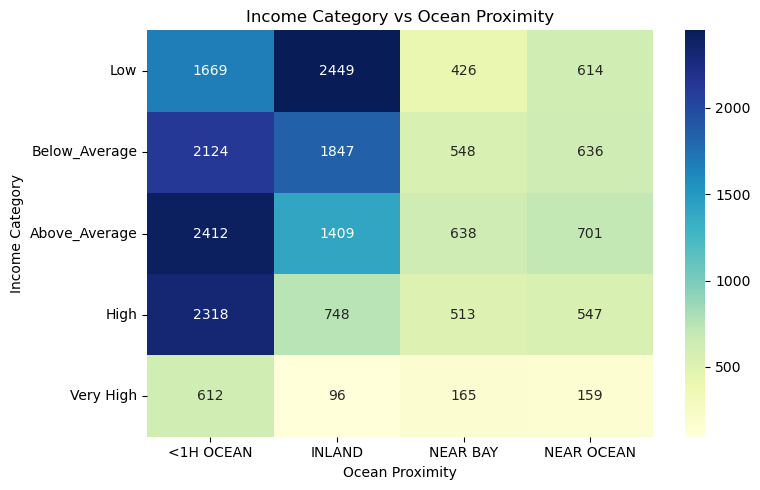

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.heatmap(
    income_ocean_pivot,
    annot=True,      # Show values in cells
    fmt="d",         # Integer format
    cmap="YlGnBu"    # Optional color palette
)

plt.title("Income Category vs Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Income Category")

plt.tight_layout()
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [48]:
df.drop(columns="income_cat", inplace=True)
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'population_per_household', 'bedrooms_per_room'],
      dtype='object')


2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`. 

In [49]:
import scipy.stats as stats
import numpy as np

# Select float columns
float_cols = df.select_dtypes(include=["float64"])



In [50]:
# Apply Z-score standardization
z_scored = float_cols.apply(lambda x: stats.zscore(x))

# View the result
print(z_scored.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327701  1.052665            0.982224    -0.804958       -0.975370   
1  -1.322710  1.043301           -0.606873     2.045696        1.354918   
2  -1.332692  1.038619            1.856227    -0.535890       -0.829876   
3  -1.337683  1.038619            1.856227    -0.624357       -0.722544   
4  -1.337683  1.038619            1.856227    -0.462549       -0.615213   

   population  households  median_income  median_house_value  \
0   -0.974710   -0.977332       2.344595            2.129854   
1    0.861243    1.669812       2.332068            1.314311   
2   -0.821052   -0.843928       1.782561            1.258844   
3   -0.766300   -0.734067       0.932876            1.165243   
4   -0.760118   -0.629436      -0.012919            1.173043   

   rooms_per_household  population_per_household  bedrooms_per_room  
0             0.744324                 -0.049604          -0.975835  
1             0.390083  

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [51]:
import pandas as pd

# Create dummy variables and drop the first category
dummies = pd.get_dummies(
    df["ocean_proximity"],
    prefix="ocean",
    drop_first=True,
    dtype=int
)

# Add dummies to the dataset and remove the original column
df = pd.concat([df.drop(columns=["ocean_proximity"]), dummies], axis=1)

print(df.head())

print(df.columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   rooms_per_household  population_per_household  bedrooms_per_room  \
0             6.984127                  2.555556           0.146591   
1             6.238137

4. Save our predicting variable to `y`.

In [52]:
y = df["median_house_value"]

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [53]:
import pandas as pd

X = pd.concat([z_scored, dummies], axis=1).drop(columns="median_house_value")

print(X.head())
print(X.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.327701  1.052665            0.982224    -0.804958       -0.975370   
1  -1.322710  1.043301           -0.606873     2.045696        1.354918   
2  -1.332692  1.038619            1.856227    -0.535890       -0.829876   
3  -1.337683  1.038619            1.856227    -0.624357       -0.722544   
4  -1.337683  1.038619            1.856227    -0.462549       -0.615213   

   population  households  median_income  rooms_per_household  \
0   -0.974710   -0.977332       2.344595             0.744324   
1    0.861243    1.669812       2.332068             0.390083   
2   -0.821052   -0.843928       1.782561             1.363546   
3   -0.766300   -0.734067       0.932876             0.190268   
4   -0.760118   -0.629436      -0.012919             0.410842   

   population_per_household  bedrooms_per_room  ocean_INLAND  ocean_ISLAND  \
0                 -0.049604          -0.975835             0             0   
1 

# Part 4 - Machine Learning 




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16508, 15)
X_test : (4128, 15)
y_train: (16508,)
y_test : (4128,)


#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model. 

In [55]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train (fit) the model
lr_model.fit(X_train, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
# Check training score (R²)
print("Training R²:", lr_model.score(X_train, y_train))

Training R²: 0.6486407349829268


3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look? 

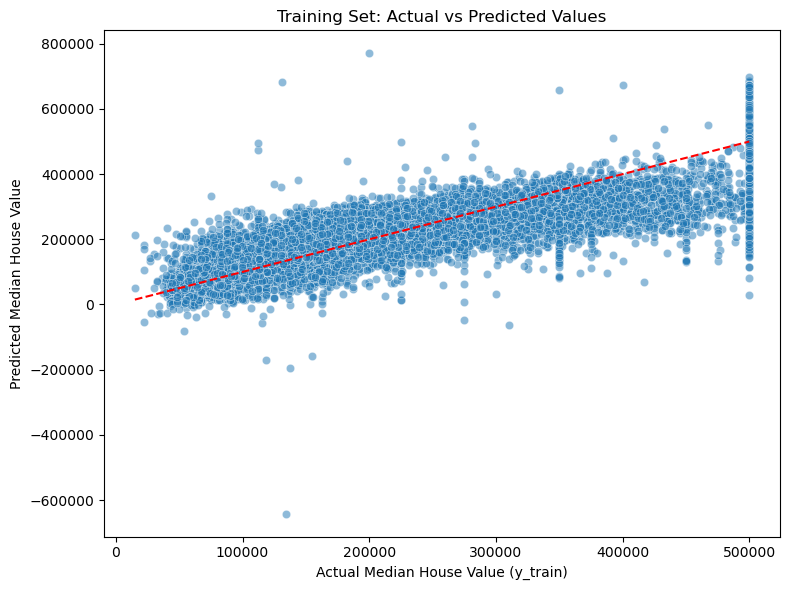

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Training predictions
y_train_pred = lr_model.predict(X_train)

# Scatterplot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_train,
    y=y_train_pred,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--'
)

plt.xlabel("Actual Median House Value (y_train)")
plt.ylabel("Predicted Median House Value")
plt.title("Training Set: Actual vs Predicted Values")

plt.tight_layout()
plt.show()

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [3]:
from sklearn import metrics

In [58]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions on test data
y_pred = lr_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



In [59]:
print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 4570038040.466852
R² Score: 0.6505688894619803


#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on the test set
y_pred = lr_model.predict(X_test)



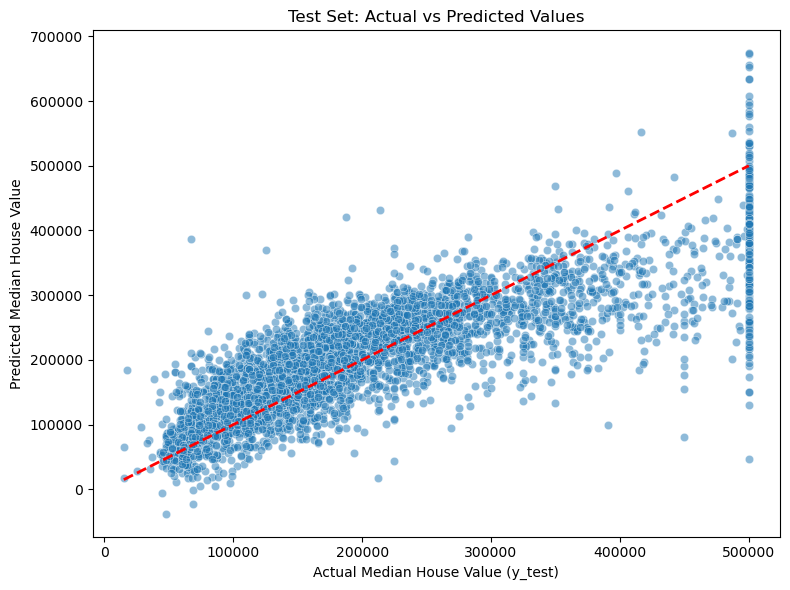

In [61]:
# Scatterplot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Median House Value (y_test)")
plt.ylabel("Predicted Median House Value")
plt.title("Test Set: Actual vs Predicted Values")

plt.tight_layout()
plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [62]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R² :", r2_score(y_test, y_pred))

MSE: 4570038040.466852
R² : 0.6505688894619803


In [ ]:
# same results

3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

In [64]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Predictions on the test set
y_pred = lr_model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

#On average, the model's predictions are off by about $67,600 from the true median house values.

RMSE: 67602.05648104836


# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

In [65]:
import pandas as pd

# Predictions on the test set
y_pred = lr_model.predict(X_test)

# Create comparison DataFrame
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(results_df.head())

         Actual      Predicted
8574   500001.0  367471.044192
1712   161000.0  239028.624597
15916  240900.0  244322.948238
5196    88700.0  148439.532375
13583   75800.0   89666.458350


2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

In [66]:
# Create predictions again (if not already available)
y_pred = lr_model.predict(X_test)

# Create DataFrame if not already created
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# Absolute errors series
absolute_errors = (results_df["Actual"] - results_df["Predicted"]).abs()

print(absolute_errors.head())

0    132529.955808
1     78028.624597
2      3422.948238
3     59739.532375
4     13866.458350
dtype: float64


3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

In [67]:
mae = absolute_errors.mean()
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 49224.01553360077


# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [68]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Check training score
print("Training R²:", rf_model.score(X_train, y_train))

Training R²: 0.9749849374182572


In [69]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)



In [70]:
# Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)



In [71]:
print("Random Forest MSE:", mse_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MSE: 2593897779.915665
Random Forest RMSE: 50930.32279414362
Random Forest R²: 0.8016671691062243


2. Make prediction on the test data and evaluate you results.

In [72]:
# Making predictions
y_pred_rf = rf_model.predict(X_test)

In [73]:
# Evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Mean Squared Error:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Mean Squared Error: 2593897779.915665
RMSE: 50930.32279414362
R² Score: 0.8016671691062243


In [ ]:
# same results